# **Step 1: Importing Libraries**

This code imports essential libraries for **data processing, visualization, deep learning, and machine learning** tasks.

### **1. Data Handling**  
- **pandas** (`pd`) – Works with structured data (tables, CSVs).  
- **numpy** (`np`) – Handles numerical computations and arrays.  

### **2. Data Visualization**  
- **matplotlib.pyplot** (`plt`) – Creates graphs and charts.  

### **3. Deep Learning**  
- **tensorflow** (`tf`, `keras`) – Builds and trains deep learning models.  
- **torch** – Used for deep learning applications.  

### **4. Machine Learning & Preprocessing**  
- **scikit-learn** – Provides tools for model training, evaluation, and feature scaling.  
  - `train_test_split` – Splits data into training and test sets.  
  - `StandardScaler` – Standardizes numerical features.  
  - `RandomForestRegressor`, `LinearRegression` – Regression models.  
  - `r2_score`, `mean_absolute_error`, `mean_squared_error` – Evaluation metrics.  

### **5. Utility Libraries**  
- **tqdm** – Displays progress bars in loops.  
- **time** – Measures execution time.  

### **6. NLP & Model Explainability**  
- **transformers** (`AutoTokenizer`, `AutoModel`) – Handles NLP tasks like text tokenization and model loading.  
- **shap** – Explains model predictions and feature importance.  

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

# Print a starting message
print("Starting housing price prediction model training...")


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tqdm.notebook import tqdm
import time
import torch
from transformers import AutoTokenizer, AutoModel
import shap

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print("Starting housing price prediction model training...")


Starting housing price prediction model training...


# **Step 2: Loading Dataset**

This section loads the cleaned housing dataset from a CSV file and measures the time taken for loading. It also prints the dataset's shape to confirm successful loading.


In [2]:
start_time = time.time()
print("Loading dataset...")
df = pd.read_csv(r"/content/drive/MyDrive/Cleaned_Housing_Data.csv")  # Replace with your actual file path
print(f"Dataset loaded in {time.time() - start_time:.2f} seconds")
print(f"Dataset shape: {df.shape}")

Loading dataset...


<ipython-input-2-d45d8fdf8b58>:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"/content/drive/MyDrive/Cleaned_Housing_Data.csv")  # Replace with your actual file path


Dataset loaded in 5.89 seconds
Dataset shape: (204164, 103)


# **Step 3: Data Inspection and Cleaning**

This section inspects the first few rows of the dataset and checks for missing values. If any null values are found, they are removed to ensure clean data for model training.


In [3]:
df.head()

,id,postal_code,price,category,year_built,garden,plot_area,num_rooms,num_bathrooms,surface_area,...,35.1,36.1,37.1,38.1,39.1,40.1,41.1,42.1,43.1,44.1
0,4388064.0,17.0,139000.0,1.0,1971-1980,1.0,208.0,3.0,1.0,62.0,...,2.207891,-1.235118,4.573564,1.318661,-1.457091,-1.618119,0.190523,0.251195,-0.360857,0.033453
1,4388200.0,74.0,209000.0,1.0,1980,1.0,148.0,5.0,1.0,136.0,...,0.030641,0.025552,0.026762,0.013864,0.025478,0.006264,0.012339,-0.022181,-0.008442,0.000781
2,4399344.0,10.0,267500.0,0.0,2001-2010,0.0,208.0,3.0,1.0,70.0,...,0.207027,-0.712891,-0.169005,0.393081,0.233442,0.522865,0.484633,-0.219489,-0.202367,0.340423
3,4400638.0,56.0,349000.0,1.0,1973,1.0,244.0,5.0,1.0,144.0,...,0.038378,0.153943,0.205131,0.219969,0.232613,0.099256,0.081190,0.068835,-0.027357,-0.178879
4,4401831.0,59.0,162500.0,1.0,1970,1.0,104.0,4.0,1.0,68.0,...,0.046540,-0.005620,0.011230,-0.036649,-0.027272,0.015323,0.026461,-0.008384,-0.010409,-0.022877


In [4]:
# Check for null values
df.isnull().sum()

,0
id,33638
postal_code,33638
price,33638
category,33638
year_built,33638
...,...
40.1,33638
41.1,33638
42.1,33638
43.1,33638


In [5]:
df = df.dropna()
print(f"Dataset shape after dropping NA: {df.shape}")

Dataset shape after dropping NA: (136888, 103)


In [6]:
# Display basic statistics of the dataset
df.describe()

,id,postal_code,price,category,garden,plot_area,num_rooms,num_bathrooms,surface_area,year_built_numeric,...,35.1,36.1,37.1,38.1,39.1,40.1,41.1,42.1,43.1,44.1
count,1.368880e+05,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,...,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000,136888.000000
mean,4.257259e+06,43.785664,269862.441741,0.682887,0.664529,195.283261,4.346108,1.033524,107.515882,1976.785682,...,-0.000526,0.000924,0.000335,-0.000497,0.000088,0.000010,-0.000461,0.000893,0.000519,0.000449
std,1.338670e+05,23.980506,106347.835329,0.465354,0.472157,57.502260,1.273392,0.184411,30.884012,35.584685,...,0.424894,0.405647,0.392582,0.367518,0.352528,0.352055,0.328527,0.317853,0.296524,0.269224
min,2.567727e+06,10.000000,215.000000,0.000000,0.000000,32.000000,1.000000,1.000000,20.000000,1005.000000,...,-5.588831,-6.393311,-9.768469,-6.791410,-6.892666,-6.008315,-5.362079,-5.778280,-3.763116,-3.567352
25%,4.143911e+06,25.000000,189937.500000,0.000000,0.000000,152.000000,3.000000,1.000000,85.000000,1961.000000,...,-0.043101,-0.005620,-0.038325,-0.000446,-0.039046,0.001776,-0.033830,-0.022182,-0.010409,-0.022880
50%,4.231248e+06,38.000000,250000.000000,1.000000,1.000000,208.000000,4.000000,1.000000,108.000000,1981.000000,...,0.030641,0.025552,0.011230,0.013863,0.006041,0.006265,0.012338,-0.008382,-0.008441,0.000780
75%,4.402036e+06,62.000000,325000.000000,1.000000,1.000000,208.000000,5.000000,1.000000,128.000000,2004.000000,...,0.046538,0.025555,0.026762,0.030015,0.025480,0.049825,0.026462,0.030424,-0.006904,0.026849
max,4.613353e+06,99.000000,637500.000000,1.000000,1.000000,371.000000,8.000000,4.000000,204.000000,2068.000000,...,11.853544,7.895109,4.573571,4.860200,4.057118,3.954984,6.767215,8.226103,4.936941,6.245760


# **Step 4: Data Type Checking and Feature Selection**

This section checks the data types of the columns to identify non-numeric features. If any categorical columns exist, they are processed using one-hot encoding. The target variable (`price`) is separated from the features for model training.


In [10]:
# Check column data types before processing
print("Checking column data types:")
print(df.dtypes)

# Analyze the problematic columns (likely containing non-numeric data)
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\nColumn '{col}' has non-numeric data. Sample values:")
        print(df[col].value_counts().head())

# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNon-numeric columns: {non_numeric_cols}")

# Extract features and target
print("\nSelecting features and target...")
# Drop price, id, and any non-numeric columns
columns_to_drop = ['price']
if 'id' in df.columns:
    columns_to_drop.append('id')

# Extract only numeric features
features = df.drop(columns=columns_to_drop)

# Handle non-numeric features with one-hot encoding
if non_numeric_cols:
    print(f"Converting categorical features using one-hot encoding: {non_numeric_cols}")
    features = pd.get_dummies(features, columns=[col for col in non_numeric_cols if col in features.columns])

labels = df['price']
print(f"Features shape after processing: {features.shape}, Labels shape: {labels.shape}")

# Check feature column names after one-hot encoding
print("\nFeature columns after processing:")
print(features.columns.tolist())


Checking column data types:
id             float64
postal_code    float64
price          float64
category       float64
year_built      object
                ...   
40.1           float64
41.1           float64
42.1           float64
43.1           float64
44.1           float64
Length: 103, dtype: object

Column 'year_built' has non-numeric data. Sample values:
year_built
2018    8924
2019    7692
1972    2470
1965    2270
1980    2082
Name: count, dtype: int64

Non-numeric columns: ['year_built']

Selecting features and target...
Converting categorical features using one-hot encoding: ['year_built']
Features shape after processing: (136888, 416), Labels shape: (136888,)

Feature columns after processing:
['postal_code', 'category', 'garden', 'plot_area', 'num_rooms', 'num_bathrooms', 'surface_area', 'year_built_numeric', 'listing_year', 'construction_year', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22',

# **Step 5: Splitting Dataset**

This section splits the dataset into **training, validation, and test sets** to ensure proper model evaluation.  
- **Training set**: Used to train the model.  
- **Validation set**: Used to tune hyperparameters and prevent overfitting.  
- **Test set**: Used for final model evaluation.

In [11]:
# Train-validation-test split
print("Splitting dataset into train, validation, and test sets...")
X_train_val, X_test, y_train_val, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Splitting dataset into train, validation, and test sets...
Training set: (82132, 416), Validation set: (27378, 416), Test set: (27378, 416)


# **Step 6: Standardizing Data**

This section standardizes the numerical features using **StandardScaler** to ensure that all features have a similar scale. This improves model performance and training stability.

In [12]:
# Standardizing data
print("Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
# Use the scaled data directly (since PCA has already been applied in the preprocessing)
X_train_final = X_train_scaled
X_val_final = X_val_scaled
X_test_final = X_test_scaled

Standardizing features...


# **Step 7: Training and Evaluating Linear Regression Model**

This section trains a **Linear Regression model** on the standardized training data and evaluates its performance using R², MAE, and RMSE metrics.

In [14]:
# 1. Linear Regression Model
print("\nTraining Linear Regression model...")
start_time = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train_final, y_train)
lin_train_time = time.time() - start_time
print(f"Linear Regression training completed in {lin_train_time:.2f} seconds")


Training Linear Regression model...
Linear Regression training completed in 2.70 seconds


In [15]:
# Evaluate Linear Regression
lin_pred = lin_reg.predict(X_test_final)
lin_r2 = r2_score(y_test, lin_pred)
lin_mae = mean_absolute_error(y_test, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))
print(f"Linear Regression: R² = {lin_r2:.4f}, MAE = {lin_mae:.2f}, RMSE = {lin_rmse:.2f}")

Linear Regression: R² = 0.5868, MAE = 51111.71, RMSE = 68137.21


# **Step 8: Training and Evaluating Random Forest Model**

This section trains a **Random Forest model**, a powerful ensemble learning technique, on the standardized training data. The model uses multiple decision trees to improve accuracy and reduce overfitting. The training process is tracked using `tqdm` for better visibility. After training, the model is evaluated using R², MAE, and RMSE metrics.


In [16]:
# 2. Random Forest Model
print("\nTraining Random Forest model...")
start_time = time.time()

# Create and train the Random Forest model with tqdm for tracking
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Use tqdm to track progress
with tqdm(total=1, desc="Random Forest Training") as pbar:
    rf_model.fit(X_train_final, y_train)
    pbar.update(1)

rf_train_time = time.time() - start_time
print(f"Random Forest training completed in {rf_train_time:.2f} seconds")



Training Random Forest model...


Random Forest Training:   0%|          | 0/1 [00:00<?, ?it/s]

Random Forest training completed in 1623.29 seconds


In [17]:
# Evaluate Random Forest
rf_pred = rf_model.predict(X_test_final)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"Random Forest: R² = {rf_r2:.4f}, MAE = {rf_mae:.2f}, RMSE = {rf_rmse:.2f}")

Random Forest: R² = 0.7616, MAE = 37028.93, RMSE = 51753.63


# **Step 9: Building the Neural Network Model**

This section defines a **Neural Network model** using TensorFlow's Keras API. The model consists of multiple layers:
- **Input Layer**: Accepts features as input.
- **Hidden Layers**:
  - Three fully connected layers (`Dense`) with ReLU activation.
  - **Batch Normalization** to stabilize training.
  - **Dropout** (20%) to prevent overfitting.
- **Output Layer**: Single neuron for regression (predicting house prices).

The model is compiled using the **Adam optimizer** with a learning rate of 0.001 and Mean Squared Error (MSE) as the loss function.

In [18]:
# 3. Neural Network Model
def create_neural_network_model(input_dim):
    model = keras.Sequential([
        # Input layer
        keras.layers.Input(shape=(input_dim,)),

        # First hidden layer
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),

        # Second hidden layer
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),

        # Third hidden layer
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),

        # Output layer for regression
        keras.layers.Dense(1)
    ])

    # Compile model
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

# **Step 10: Training and Evaluating the Neural Network Model**

This section initializes, compiles, trains, and evaluates the **Neural Network model**. It includes:
- **Model Summary**: Displays the architecture of the neural network.
- **Early Stopping**: Stops training when validation loss does not improve for 10 epochs, preventing overfitting.
- **Training Process**: Uses 100 epochs with a batch size of 32.
- **Evaluation Metrics**: Measures performance using R², MAE, and RMSE.

In [19]:
# Create and train the neural network
print("\nTraining Neural Network model...")
input_dim = X_train_final.shape[1]
nn_model = create_neural_network_model(input_dim)


Training Neural Network model...


In [20]:
# Display model summary
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          53,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,641 (252.50 KB)

 Trainable params: 64,193 (250.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
# Use early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [66]:
import time

start_time = time.time()
history = nn_model.fit(
    X_train_final, y_train,
    validation_data=(X_val_final, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],  # Removed TqdmCallbackNotebook()
    verbose=0  # Set verbose=0 to disable output
)
nn_train_time = time.time() - start_time
print(f"Neural Network training completed in {nn_train_time:.2f} seconds")


Neural Network training completed in 138.22 seconds


In [56]:
# Evaluate Neural Network
nn_pred = nn_model.predict(X_test_final, verbose=0).flatten()
nn_r2 = r2_score(y_test, nn_pred)
nn_mae = mean_absolute_error(y_test, nn_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
print(f"Neural Network: R² = {nn_r2:.4f}, MAE = {nn_mae:.2f}, RMSE = {nn_rmse:.2f}")

Neural Network: R² = 0.2984, MAE = 65254.11, RMSE = 88792.71


# **Step 11: Visualizing Neural Network Training History**

This section plots the training and validation **loss** and **mean absolute error (MAE)** over epochs to analyze the model's performance and detect potential overfitting.


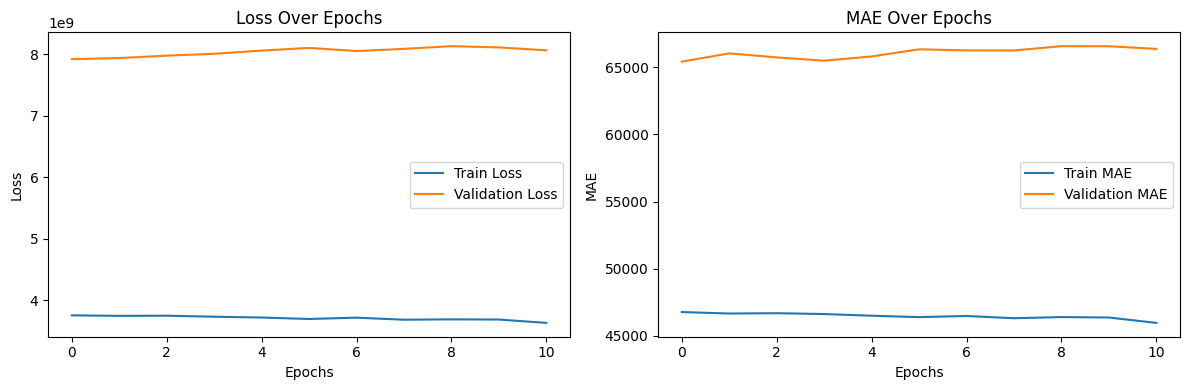

In [57]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.savefig('neural_network_training.png')
plt.show()

# **Step 12: Model Comparison Visualization**

This section compares the performance of different models using key metrics:
- **R² Score**: Measures how well the model explains variance in the data.
- **Mean Absolute Error (MAE)**: Average absolute difference between predictions and actual values.
- **Root Mean Squared Error (RMSE)**: Measures model accuracy by penalizing large errors.


In [58]:
# Model Comparison Visualization
print("\nCreating model comparison visualizations...")
models = ['Linear Regression', 'Random Forest', 'Neural Network']
r2_scores = [lin_r2, rf_r2, nn_r2]
mae_scores = [lin_mae, rf_mae, nn_mae]
rmse_scores = [lin_rmse, rf_rmse, nn_rmse]


Creating model comparison visualizations...


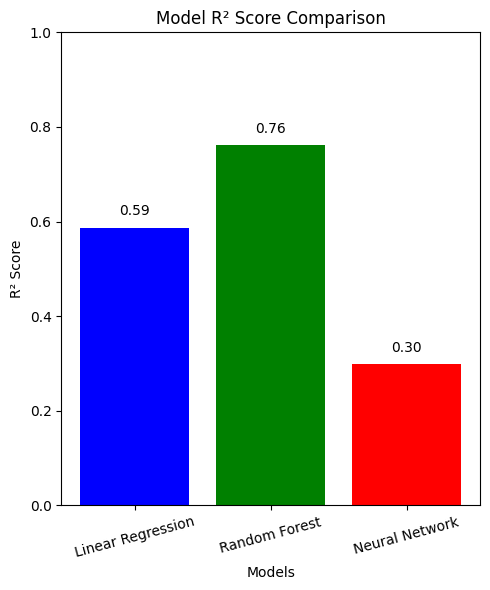

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 6))

# R² Score Comparison
bars = plt.bar(models, r2_scores, color=['blue', 'green', 'red'])

# Labels
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Model R² Score Comparison")

# Adjusting text placement
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.,
             height + 0.02,  # Increased offset for better visibility
             f'{height:.2f}', ha='center', va='bottom')

plt.ylim(0, 1)  # Set y-axis limit for R² scores
plt.xticks(rotation=15)  # Rotate x-labels for readability
plt.tight_layout()
plt.savefig('model_r2_comparison.png')
plt.show()


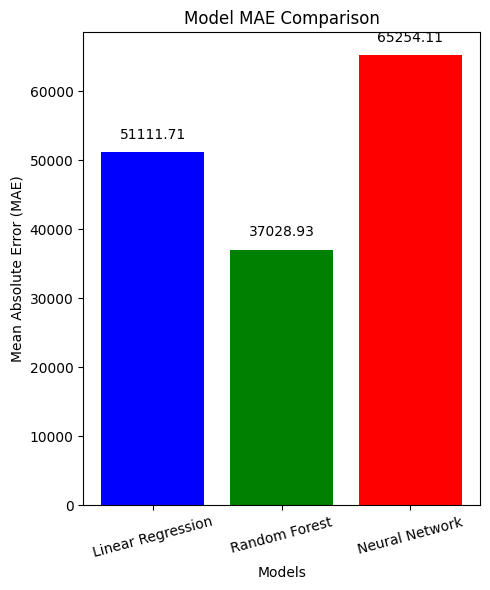

In [60]:
plt.figure(figsize=(5, 6))

# MAE Comparison
bars = plt.bar(models, mae_scores, color=['blue', 'green', 'red'])

# Labels
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Model MAE Comparison")

# Adjusting text placement
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.,
             height + 1500,  # Adjust offset based on MAE values
             f'{height:.2f}', ha='center', va='bottom')

plt.xticks(rotation=15)  # Rotate x-labels for readability
plt.tight_layout()
plt.savefig('model_mae_comparison.png')
plt.show()


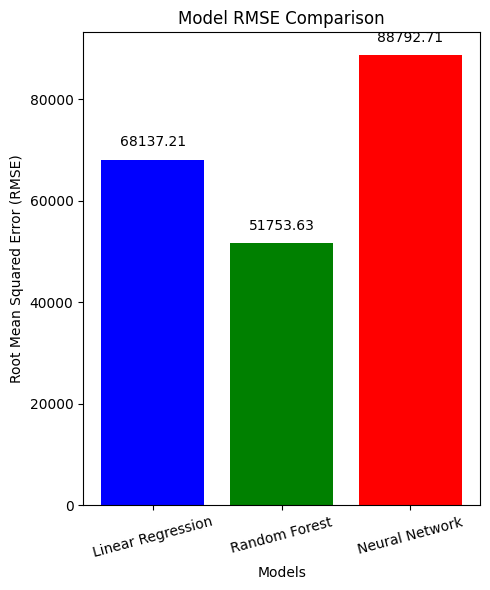

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 6))

# RMSE Comparison
bars = plt.bar(models, rmse_scores, color=['blue', 'green', 'red'])

# Labels
plt.xlabel("Models")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Model RMSE Comparison")

# Adjusting text placement
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.,
             height + 2000,  # Adjust offset based on RMSE values
             f'{height:.2f}', ha='center', va='bottom')

plt.xticks(rotation=15)  # Rotate x-labels for readability
plt.tight_layout()
plt.savefig('model_rmse_comparison.png')
plt.show()


# **Step 13: Feature Importance Analysis**

This section analyzes the **most influential features** in the **Random Forest model**. The top 15 features are displayed and visualized to understand which factors contribute most to price prediction.


Analyzing Random Forest feature importance...

Top 15 features by importance:
               Feature  Importance
0         surface_area    0.395639
1          postal_code    0.238009
2   year_built_numeric    0.090128
3            plot_area    0.032048
4             category    0.011659
5            num_rooms    0.004214
6                    0    0.003989
7                   33    0.003892
8                   15    0.003873
9                   41    0.003863
10                  29    0.003838
11                  20    0.003809
12                  27    0.003808
13                  32    0.003796
14                  10    0.003773


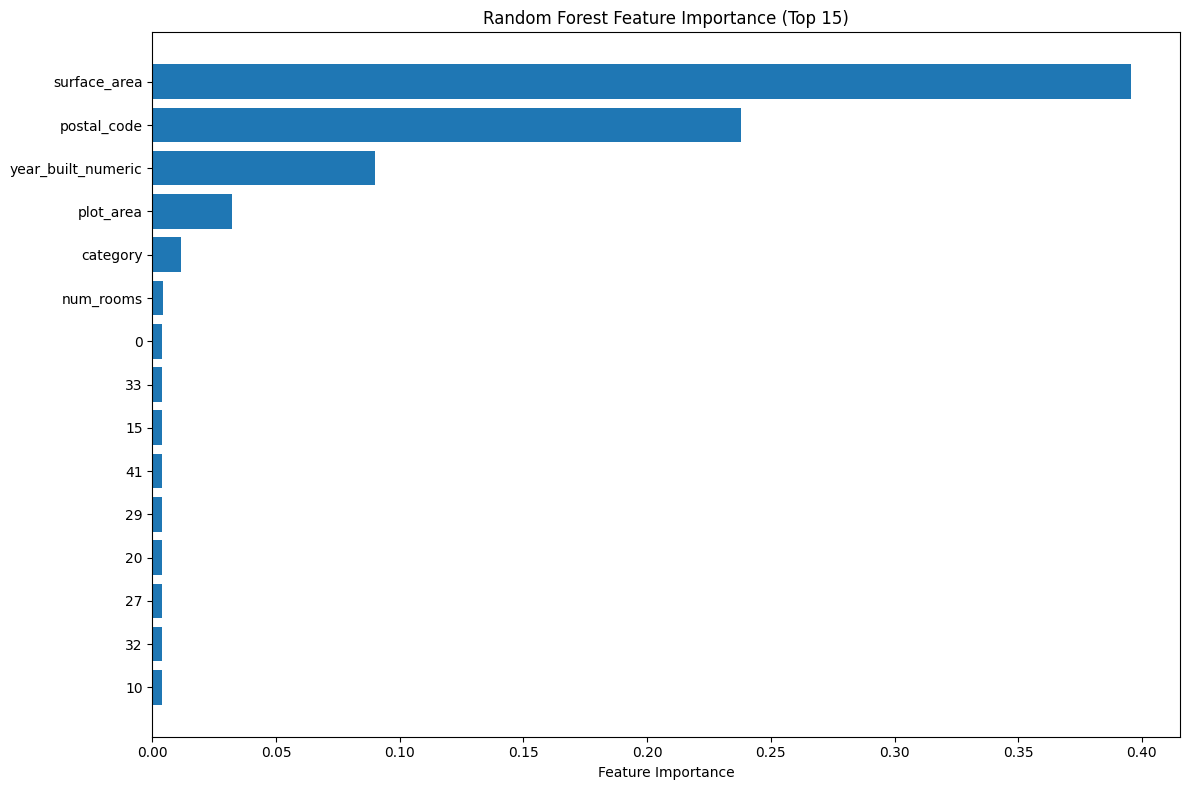


********** TOP 5 IMPORTANT FEATURES **********
           Feature  Importance
      surface_area    0.395639
       postal_code    0.238009
year_built_numeric    0.090128
         plot_area    0.032048
          category    0.011659
*****************************************************************

Top 5 features saved to 'top_5_features.csv'


In [63]:
# Feature Importance for Random Forest
print("\nAnalyzing Random Forest feature importance...")
if hasattr(rf_model, 'feature_importances_'):
    feature_importance = rf_model.feature_importances_

    # Get actual feature names from the dataframe (after one-hot encoding)
    feature_names = features.columns.tolist()

    # Create a DataFrame to store feature importances
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    })

    # Sort by importance (descending)
    importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)

    # Display the top 15 features
    print("\nTop 15 features by importance:")
    print(importance_df.head(15))

    # Visualize the top 15 features
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15], align='center')
    plt.xlabel("Feature Importance")
    plt.title("Random Forest Feature Importance (Top 15)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('rf_feature_importance.png')
    plt.show()

    # Highlight the top 5 features (client requirement)
    print("\n********** TOP 5 IMPORTANT FEATURES **********")
    print(importance_df[['Feature', 'Importance']].head(5).to_string(index=False))
    print("*****************************************************************")

    # Save top features to a separate file
    top_features_df = importance_df.head(5)
    top_features_df.to_csv('top_5_features.csv', index=False)
    print("\nTop 5 features saved to 'top_5_features.csv'")


##- **`surface_area`** is the most important feature, contributing significantly to predictions.
##- **`postal_code`** plays a key role, indicating that location has a major impact.
##- **`year_built_numeric`** suggests that the age of the property affects the target variable.
##- Features like **`plot_area`** and **`category`** have lower but still relevant importance.
##- **`num_rooms`** has the least impact among the top-ranked features.

# **Step 14: Counterfactual Analysis**

This section analyzes how changing key features impacts predictions, helping understand model behavior.



Performing counterfactual analysis...
Testing 10 different values for Feature_6...


Counterfactual analysis:   0%|          | 0/10 [00:00<?, ?it/s]

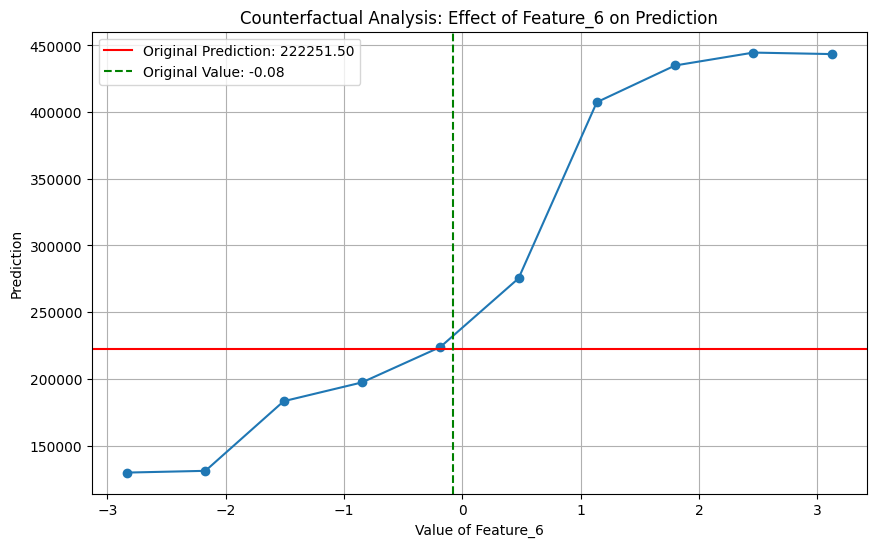

In [64]:

# Counterfactual Analysis
print("\nPerforming counterfactual analysis...")
def perform_counterfactual_analysis(model, X_data, feature_names, instance_idx=0, feature_to_change=None, n_changes=10):
    """
    Perform counterfactual analysis by changing feature values and observing the effect on prediction.
    """
    # Get the reference instance
    instance = X_data[instance_idx:instance_idx+1].copy()
    original_prediction = model.predict(instance)[0]

    if feature_to_change is None:
        # If no feature specified, use the most important feature for Random Forest
        if hasattr(model, 'feature_importances_'):
            feature_to_change = np.argmax(model.feature_importances_)
        else:
            feature_to_change = 0

    feature_name = feature_names[feature_to_change]

    # Calculate the range of values to try
    feature_min = X_data[:, feature_to_change].min()
    feature_max = X_data[:, feature_to_change].max()

    # Try different values
    test_values = np.linspace(feature_min, feature_max, n_changes)
    predictions = []

    print(f"Testing {n_changes} different values for {feature_name}...")
    for val in tqdm(test_values, desc="Counterfactual analysis"):
        modified = instance.copy()
        modified[0, feature_to_change] = val
        pred = model.predict(modified)[0]
        predictions.append(pred)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(test_values, predictions, 'o-')
    plt.axhline(y=original_prediction, color='r', linestyle='-', label=f'Original Prediction: {original_prediction:.2f}')
    plt.axvline(x=instance[0, feature_to_change], color='g', linestyle='--',
                label=f'Original Value: {instance[0, feature_to_change]:.2f}')
    plt.xlabel(f'Value of {feature_name}')
    plt.ylabel('Prediction')
    plt.title(f'Counterfactual Analysis: Effect of {feature_name} on Prediction')
    plt.legend()
    plt.grid(True)
    plt.savefig('counterfactual_analysis.png')
    plt.show()

    return test_values, predictions

# Generate feature names
feature_names = [f"Feature_{i}" for i in range(X_test_final.shape[1])]

# Perform counterfactual analysis on Random Forest model
test_values, predictions = perform_counterfactual_analysis(
    rf_model,
    X_test_final,
    feature_names,
    instance_idx=0,
    feature_to_change=None,  # Use most important feature
    n_changes=10
)

# **Step 15: SHAP Analysis for Model Explainability**

### Overview
SHAP (**SHapley Additive exPlanations**) is used to interpret the predictions of the **Random Forest model**. This analysis helps identify the most important features influencing model predictions.



Calculating SHAP values for model explainability...


<ipython-input-65-0933ac3dfe16>:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)


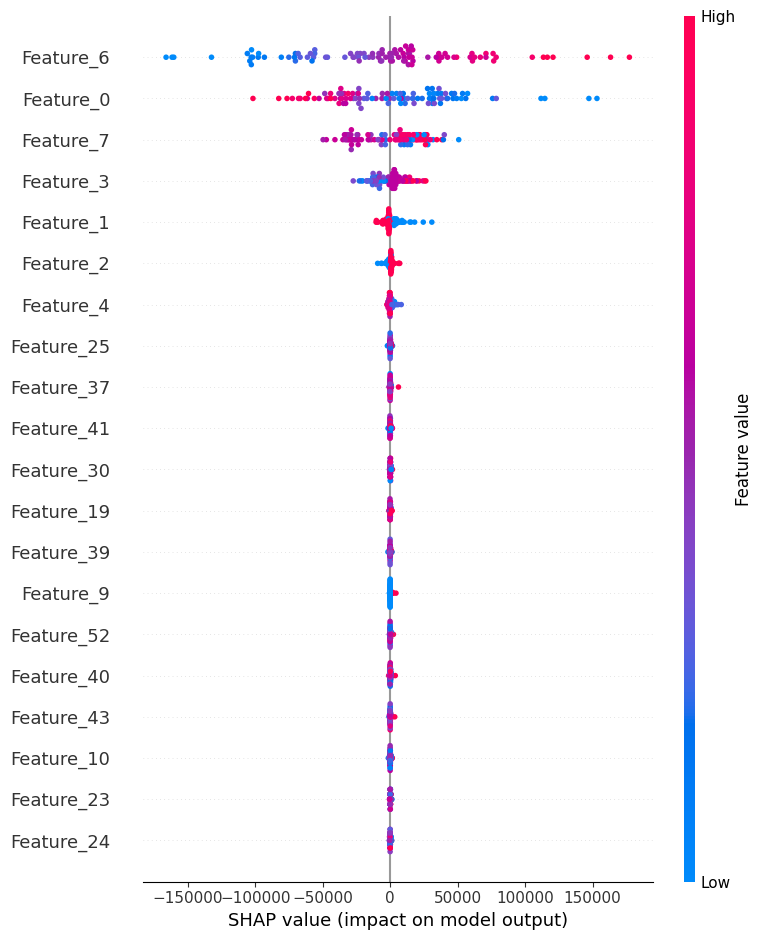

SHAP analysis completed and saved as 'shap_summary.png'


In [65]:
# SHAP Analysis (in a try-except block to handle potential issues)
try:
    print("\nCalculating SHAP values for model explainability...")
    # Select a subset of test data for SHAP analysis
    sample_size = min(100, X_test_final.shape[0])
    X_shap = X_test_final[:sample_size]

    # Create SHAP explainer for Random Forest model
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_shap)

    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary.png')
    plt.show()

    print("SHAP analysis completed and saved as 'shap_summary.png'")
except Exception as e:
    print(f"Error in SHAP analysis: {e}")
    print("Continuing without SHAP analysis.")

# **Step 16: Model Selection and Evaluation**
### Overview
This section compares the performance of three machine learning models—**Linear Regression**, **Random Forest**, and **Neural Network**—using three evaluation metrics:  
- **R² (R-squared):** Measures how well the model explains variance in the target variable. A higher value indicates a better fit.  
- **MAE (Mean Absolute Error):** Represents the average absolute error between predicted and actual values. Lower values indicate better accuracy.  
- **RMSE (Root Mean Squared Error):** A measure of prediction error that gives higher weight to larger errors. Lower values indicate better model performance.  


In [37]:
# Model Selection
print("\nFinal Model Comparison:")
print(f"Linear Regression: R² = {lin_r2:.4f}, MAE = {lin_mae:.2f}, RMSE = {lin_rmse:.2f}")
print(f"Random Forest: R² = {rf_r2:.4f}, MAE = {rf_mae:.2f}, RMSE = {rf_rmse:.2f}")
print(f"Neural Network: R² = {nn_r2:.4f}, MAE = {nn_mae:.2f}, RMSE = {nn_rmse:.2f}")

# Determine the best model based on R² score
best_r2 = max(lin_r2, rf_r2, nn_r2)
if best_r2 == lin_r2:
    best_model_name = "Linear Regression"
    best_model = lin_reg
elif best_r2 == rf_r2:
    best_model_name = "Random Forest"
    best_model = rf_model
else:
    best_model_name = "Neural Network"
    best_model = nn_model

print(f"\nBest performing model: {best_model_name} with R² = {best_r2:.4f}")


Final Model Comparison:
Linear Regression: R² = 0.5868, MAE = 51111.71, RMSE = 68137.21
Random Forest: R² = 0.7616, MAE = 37028.93, RMSE = 51753.63
Neural Network: R² = 0.3140, MAE = 64668.29, RMSE = 87798.09

Best performing model: Random Forest with R² = 0.7616


# **Step 17: Saving Model Training Summary to File**

### Overview
This section of the code generates a **summary of the model training process** and saves it to a text file named **`model_training_summary.txt`**. The summary includes:
- Dataset details (size, training/validation/test split)
- Performance metrics for each model
- The best-performing model based on **R² score**  

In [38]:
# Save summary of results to file
with open('model_training_summary.txt', 'w') as f:
    f.write("MODEL TRAINING SUMMARY\n")
    f.write("=====================\n\n")
    f.write(f"Dataset size: {df.shape}\n")
    f.write(f"Training set: {X_train.shape[0]} samples\n")
    f.write(f"Validation set: {X_val.shape[0]} samples\n")
    f.write(f"Test set: {X_test.shape[0]} samples\n\n")

    f.write("MODEL PERFORMANCE (Test Set)\n")
    f.write(f"Linear Regression: R² = {lin_r2:.4f}, MAE = {lin_mae:.2f}, RMSE = {lin_rmse:.2f}\n")
    f.write(f"Random Forest: R² = {rf_r2:.4f}, MAE = {rf_mae:.2f}, RMSE = {rf_rmse:.2f}\n")
    f.write(f"Neural Network: R² = {nn_r2:.4f}, MAE = {nn_mae:.2f}, RMSE = {nn_rmse:.2f}\n\n")

    f.write(f"Best performing model: {best_model_name} with R² = {best_r2:.4f}\n")

print("\nTraining summary saved to 'model_training_summary.txt'")
print("All visualizations have been saved as PNG files.")
print("\nModel training process completed successfully!")


Training summary saved to 'model_training_summary.txt'
All visualizations have been saved as PNG files.

Model training process completed successfully!
